# RNA-seq processing and quality assessment
## Representative GSE249477 blood samples

This notebook documents the read-to-count workflow performed for two
representative samples from GSE249477 and interprets the recorded quality
metrics. The primary disease comparison is performed in the accompanying
notebook with all 21 Alzheimer's disease (AD) and 21 cognitively normal
(CN) samples. The two samples here demonstrate raw-read processing; they
are not used alone for statistical differential-expression inference.

## 1. Samples and processing question

| SRA run | GEO sample | Condition | Age | Sex | Tissue | Reads |
|---|---|---:|---:|---|---|---|
| SRR27109181 | GSM7948717 | CN | 82 | male | blood | 76-bp single-end |
| SRR27109215 | GSM7948684 | AD | 82 | male | blood | 76-bp single-end |

Using age- and sex-matched exemplars reduces obvious demographic
differences during workflow inspection. It does not create replication:
biological conclusions require the full cohort analysed in the main report.

The processing questions are:

1. Were the public reads retrieved and checked successfully?
2. What fraction mapped uniquely to hg19/GRCh37 with STAR?
3. How many uniquely mapped reads were assigned to GENCODE v19 genes?
4. Which technical limitations must be addressed before scaling the
   workflow to all samples?

In [1]:
import platform

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
print("Python:", platform.python_version())

from pathlib import Path
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
FIGURE_DIR = PROJECT_ROOT / "results" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


Python: 3.12.13


## 2. Public-read retrieval and FastQC

The recorded run downloaded 3,604,129 CN reads and 2,354,742 AD reads.
FastQC completed for both FASTQ files and produced HTML and ZIP reports.
The archived notebook confirms report generation but does not retain the
individual FastQC module results; no unsupported pass/fail claim is made.

A compact equivalent of the executed commands is:

```bash
fasterq-dump SRR27109181 --threads 4 --outdir fastq
fasterq-dump SRR27109215 --threads 4 --outdir fastq
mv fastq/SRR27109181.fastq fastq/CN_SRR27109181.fastq
mv fastq/SRR27109215.fastq fastq/AD_SRR27109215.fastq
fastqc --threads 4 --outdir qc/fastqc fastq/*.fastq
multiqc qc/fastqc --outdir qc/multiqc_raw
```

Per-base quality, adapter content, duplication, overrepresented sequences,
and sequence-length distribution should be reviewed before alignment.
QuantSeq reads can show protocol-specific 3-prime composition patterns, so
warnings require interpretation rather than automatic exclusion.

## 3. STAR alignment to hg19/GRCh37

Reads were aligned against the teaching-server hg19 STAR index with unique
alignments requested. The cleaned command below writes a sorted BAM
directly and avoids the large SAM intermediate created in the first run.

```bash
STAR --genomeDir /mnt/storage/data/resources/hg19_star_db \
     --runThreadN 10 \
     --outFilterMultimapNmax 1 \
     --readFilesIn fastq/CN_SRR27109181.fastq \
     --outSAMtype BAM SortedByCoordinate \
     --outFileNamePrefix bam/CN_

STAR --genomeDir /mnt/storage/data/resources/hg19_star_db \
     --runThreadN 10 \
     --outFilterMultimapNmax 1 \
     --readFilesIn fastq/AD_SRR27109215.fastq \
     --outSAMtype BAM SortedByCoordinate \
     --outFileNamePrefix bam/AD_
```

In [2]:
mapping_qc = pd.DataFrame({
    "condition": ["CN", "AD"],
    "run": ["SRR27109181", "SRR27109215"],
    "input_reads": [3_604_129, 2_354_742],
    "unique_reads": [2_682_059, 1_568_533],
    "unique_percent": [74.42, 66.61],
    "too_many_loci_percent": [10.74, 11.71],
    "too_short_percent": [14.73, 21.60],
    "other_unmapped_percent": [0.11, 0.07],
    "mismatch_percent": [1.97, 2.27],
})
display(mapping_qc.style.format({
    "input_reads": "{:,}", "unique_reads": "{:,}",
    "unique_percent": "{:.2f}%", "too_many_loci_percent": "{:.2f}%",
    "too_short_percent": "{:.2f}%", "other_unmapped_percent": "{:.2f}%",
    "mismatch_percent": "{:.2f}%",
}))

,condition,run,input_reads,unique_reads,unique_percent,too_many_loci_percent,too_short_percent,other_unmapped_percent,mismatch_percent
0,CN,SRR27109181,"3,604,129","2,682,059",74.42%,10.74%,14.73%,0.11%,1.97%
1,AD,SRR27109215,"2,354,742","1,568,533",66.61%,11.71%,21.60%,0.07%,2.27%


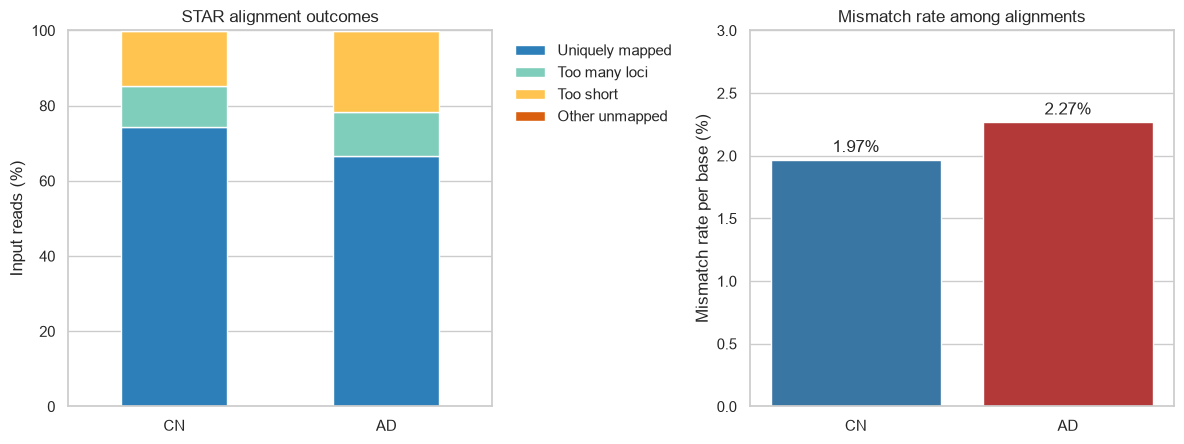

In [3]:
mapping_components = mapping_qc.set_index("condition")[
    ["unique_percent", "too_many_loci_percent", "too_short_percent",
     "other_unmapped_percent"]
]
mapping_components.columns = [
    "Uniquely mapped", "Too many loci", "Too short", "Other unmapped"
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
mapping_components.plot(
    kind="bar", stacked=True, ax=axes[0],
    color=["#2C7FB8", "#7FCDBB", "#FEC44F", "#D95F0E"]
)
axes[0].set(
    title="STAR alignment outcomes", xlabel="", ylabel="Input reads (%)",
    ylim=(0, 100),
)
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")

sns.barplot(
    data=mapping_qc, x="condition", y="mismatch_percent",
    hue="condition", legend=False, palette={"CN": "#2878B5", "AD": "#C82423"},
    ax=axes[1],
)
axes[1].set(
    title="Mismatch rate among alignments", xlabel="",
    ylabel="Mismatch rate per base (%)", ylim=(0, 3),
)
for patch, value in zip(axes[1].patches, mapping_qc["mismatch_percent"]):
    axes[1].text(
        patch.get_x() + patch.get_width() / 2, value + 0.06,
        f"{value:.2f}%", ha="center"
    )
fig.tight_layout()
fig.savefig(FIGURE_DIR / "06_processing_mapping_qc.png", dpi=180, bbox_inches="tight")
plt.show()

The CN exemplar mapped more efficiently (74.42% unique) than the AD
exemplar (66.61%). The largest difference is the fraction classified as
too short: 14.73% versus 21.60%. Mismatch rates are similar (1.97% and
2.27%). This may reflect sample/library quality, but two samples cannot
establish a disease-associated technical pattern. Across the full cohort,
mapping-rate distributions and outliers should be examined before counting.

## 4. BAM processing and visual inspection

The executed run converted STAR output to coordinate-sorted, indexed BAM
files. A storage-efficient equivalent is:

```bash
samtools index bam/CN_Aligned.sortedByCoord.out.bam
samtools index bam/AD_Aligned.sortedByCoord.out.bam
samtools flagstat bam/CN_Aligned.sortedByCoord.out.bam > qc/CN.flagstat.txt
samtools flagstat bam/AD_Aligned.sortedByCoord.out.bam > qc/AD.flagstat.txt
samtools idxstats bam/CN_Aligned.sortedByCoord.out.bam > qc/CN.idxstats.tsv
samtools idxstats bam/AD_Aligned.sortedByCoord.out.bam > qc/AD.idxstats.tsv
```

In IGV, the BAM/BAI files should be loaded with the matching hg19 reference
and GENCODE v19 annotation. Inspection should include highly expressed
blood genes (for example HBB and HBA1/HBA2), candidate loci, exon overlap,
strand orientation, and the expected 3-prime coverage pattern. IGV is a
qualitative QC step and must not replace the cohort-level statistical test.

## 5. Gene counting with featureCounts

The recorded run used GENCODE v19, gene-level aggregation by `gene_name`,
minimum mapping quality 10, and unstranded counting:

```bash
featureCounts -T 8 -Q 10 -s 0 \
  -g gene_name \
  -a gencode.v19.nopseudo.plus.sort.gtf \
  -o counts/gene_counts.tsv \
  bam/CN_Aligned.sortedByCoord.out.bam \
  bam/AD_Aligned.sortedByCoord.out.bam
```

The library preparation is directional; therefore `-s 0` is a limitation
of the recorded run. Before scaling, strandness should be verified on
representative BAMs and `-s 1` or `-s 2` selected when supported. Assignment
rates under all three settings provide a useful empirical check.

In [4]:
counting_qc = pd.DataFrame({
    "condition": ["CN", "AD"],
    "uniquely_mapped": [2_682_059, 1_568_533],
    "assigned": [817_972, 502_257],
    "no_feature": [1_811_689, 1_033_655],
    "ambiguity": [52_398, 32_621],
})
counting_qc["assigned_percent"] = (
    counting_qc["assigned"] / counting_qc["uniquely_mapped"] * 100
)
display(counting_qc.style.format({
    "uniquely_mapped": "{:,}", "assigned": "{:,}",
    "no_feature": "{:,}", "ambiguity": "{:,}",
    "assigned_percent": "{:.1f}%",
}))

,condition,uniquely_mapped,assigned,no_feature,ambiguity,assigned_percent
0,CN,"2,682,059","817,972","1,811,689","52,398",30.5%
1,AD,"1,568,533","502,257","1,033,655","32,621",32.0%


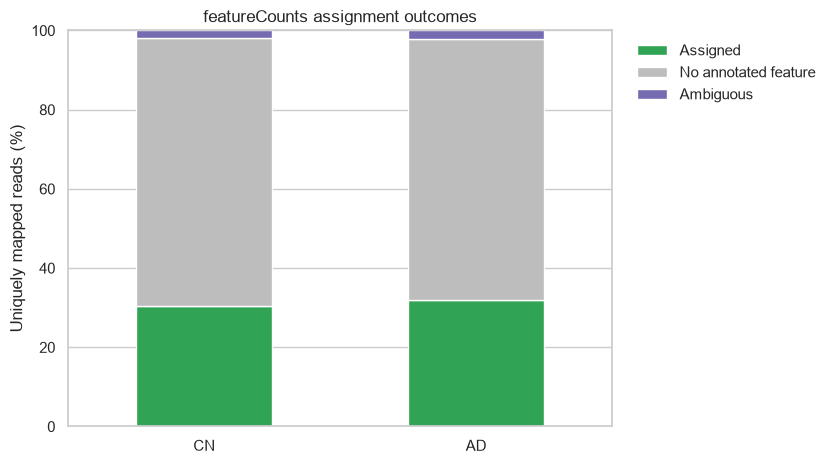

In [5]:
assignment_plot = counting_qc.set_index("condition")[
    ["assigned", "no_feature", "ambiguity"]
].div(counting_qc.set_index("condition")["uniquely_mapped"], axis=0) * 100
assignment_plot.columns = ["Assigned", "No annotated feature", "Ambiguous"]

ax = assignment_plot.plot(
    kind="bar", stacked=True, figsize=(8.5, 4.8),
    color=["#31A354", "#BDBDBD", "#756BB1"]
)
ax.set(
    title="featureCounts assignment outcomes", xlabel="",
    ylabel="Uniquely mapped reads (%)", ylim=(0, 100),
)
ax.tick_params(axis="x", rotation=0)
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "07_processing_count_assignment.png", dpi=180, bbox_inches="tight")
plt.show()

Assignment rates are similar in the two exemplars: 30.5% for CN and 32.0%
for AD. Most uniquely mapped reads were classified as `NoFeatures`. That
could reflect the 3-prime protocol, reference/annotation compatibility,
strandness, or reads outside annotated exons. Because the rates are low,
strandness and annotation compatibility are priority checks before using a
newly generated count matrix for inference.

## 6. Count-level reasonableness checks

,gene,CN,AD
0,HBB,68929,38897
1,HBA2,26191,28887
2,MALAT1,19388,7907
3,MT-RNR2,13886,11667
4,HBA1,11102,19300
5,SLC25A37,5781,2850
6,SLC25A39,3963,2968
7,OAZ1,3876,2947
8,TXNIP,3452,2346
9,MT-RNR1,3387,2383


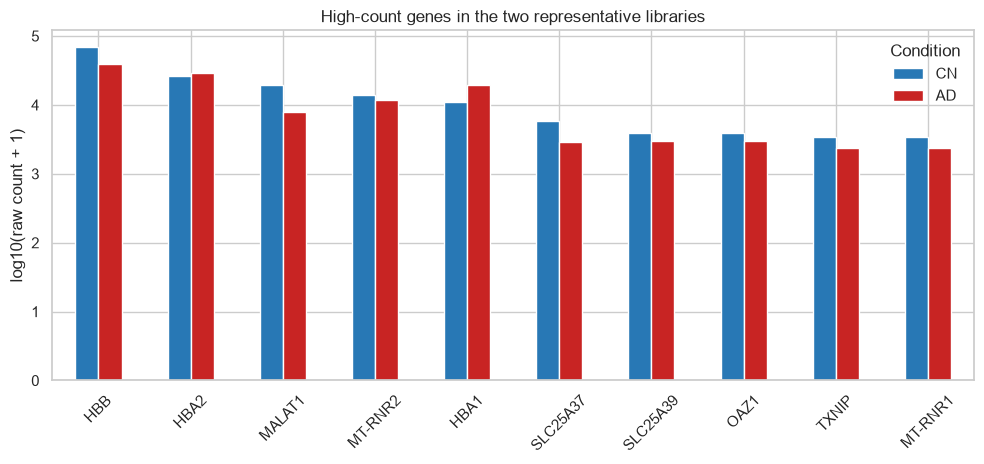

In [6]:
count_examples = pd.DataFrame({
    "gene": ["HBB", "HBA2", "MALAT1", "MT-RNR2", "HBA1",
             "SLC25A37", "SLC25A39", "OAZ1", "TXNIP", "MT-RNR1",
             "TP53", "CLEC5A"],
    "CN": [68929, 26191, 19388, 13886, 11102, 5781, 3963, 3876,
           3452, 3387, 16, 20],
    "AD": [38897, 28887, 7907, 11667, 19300, 2850, 2968, 2947,
           2346, 2383, 10, 0],
})
display(count_examples)

top_blood = count_examples.iloc[:10].set_index("gene")
ax = np.log10(top_blood + 1).plot(
    kind="bar", figsize=(10, 4.8), color=["#2878B5", "#C82423"]
)
ax.set(
    title="High-count genes in the two representative libraries",
    xlabel="", ylabel="log10(raw count + 1)",
)
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Condition", frameon=False)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "08_processing_high_count_genes.png", dpi=180, bbox_inches="tight")
plt.show()

Haemoglobin genes dominate both whole-blood libraries, which is plausible
and also illustrates why blood composition can drive transcriptomic
variation. TP53 (16 versus 10) and CLEC5A (20 versus 0) differ in these two
libraries, but the counts are low and there is only one sample per group.
They are QC observations, not differential-expression discoveries. The
full-cohort model in the main notebook is required for gene-level claims.

## 7. Scaling the workflow to the primary cohort

For all 42 AD/CN samples, runs should be processed sequentially to keep the
storage footprint below 100 GB. FASTQ files can be removed after a sorted,
indexed BAM and QC reports exist; SAM files should be avoided entirely.

```bash
while IFS=$'\t' read -r RUN SAMPLE CONDITION AGE SEX GEO EXPERIMENT; do
  [[ "$RUN" == "run" ]] && continue
  fasterq-dump "$RUN" --threads 4 --outdir fastq
  fastqc --threads 4 --outdir qc/fastqc "fastq/${RUN}.fastq"
  STAR --runThreadN 8 \
       --genomeDir "$STAR_INDEX" \
       --readFilesIn "fastq/${RUN}.fastq" \
       --outSAMtype BAM SortedByCoordinate \
       --outFileNamePrefix "bam/${RUN}."
  samtools index "bam/${RUN}.Aligned.sortedByCoord.out.bam"
  rm "fastq/${RUN}.fastq"
  du -sh .
done < sample_manifest.tsv
```

MultiQC should then summarise raw-read, alignment, and counting metrics.
Samples with unusual mapping, assignment, library size, or PCA position
require investigation before exclusion; exclusion rules should be stated
before reviewing disease effects.

## Conclusions

The representative raw-read workflow successfully retrieved, quality-
checked, aligned, indexed, and counted one CN and one AD blood library.
Unique mapping was 74.42% and 66.61%, while gene assignment was 30.5% and
32.0%. The higher too-short fraction in the AD exemplar and the generally
low assignment rates identify concrete QC questions for a full rerun.

These two samples are useful for demonstrating processing but insufficient
for biological inference. The accompanying analysis therefore uses the
complete 21-AD/21-CN deposited count matrix, age/sex adjustment, multiple-
testing correction, expression visualisation, candidate-gene review, and
functional gene-set analysis.

### References

- [GSE249477](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE249477)
- [SRR27109181](https://www.ncbi.nlm.nih.gov/sra/SRR27109181)
- [SRR27109215](https://www.ncbi.nlm.nih.gov/sra/SRR27109215)
- Dobin et al. (2013), STAR: [doi:10.1093/bioinformatics/bts635](https://doi.org/10.1093/bioinformatics/bts635)
- Liao et al. (2014), featureCounts: [doi:10.1093/bioinformatics/btt656](https://doi.org/10.1093/bioinformatics/btt656)